# SystemicRisk Net (EDA)

In [11]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from scipy.stats import norm, kurtosis, skew
import seaborn as sns

## Extreme events analysis

In [12]:
tickers = ['AAPL']
data = yf.download(tickers, period="1y")['Close']

returns = np.log(data / data.shift(1)).dropna()

/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_21397/2705589315.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


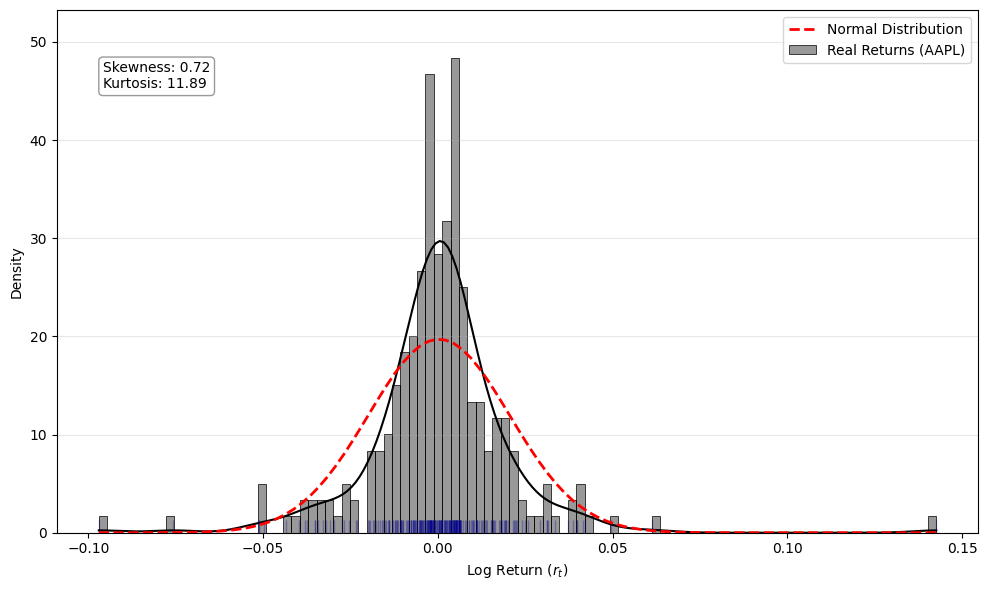

In [13]:
plt.figure(figsize=(10, 6))


sns.histplot(returns['AAPL'], kde=True, stat="density", bins=100, 
             color='black', alpha=0.4, label='Real Returns (AAPL)')


sns.rugplot(returns['AAPL'], color='darkblue', alpha=0.3)


x = np.linspace(returns['AAPL'].min(), returns['AAPL'].max(), 100)
y = norm.pdf(x, returns['AAPL'].mean(), returns['AAPL'].std())
plt.plot(x, y, 'r--', lw=2, label='Normal Distribution')



plt.xlabel('Log Return ($r_t$)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)


textstr = f'Skewness: {skew(returns["AAPL"]):.2f}\nKurtosis: {kurtosis(returns["AAPL"]):.2f}'
plt.gca().annotate(textstr, xy=(0.05, 0.85), xycoords='axes fraction', 
                   bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

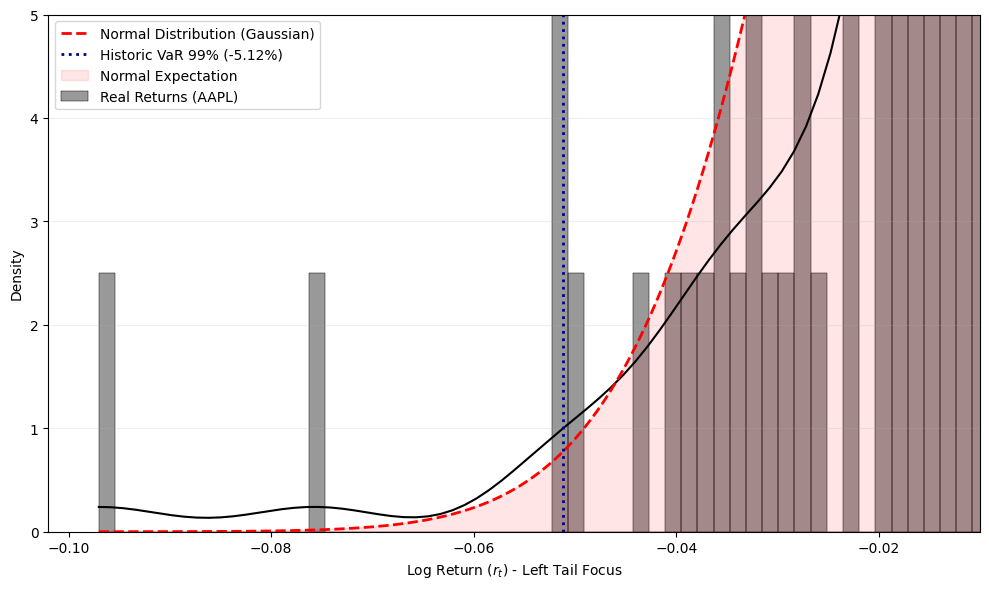

In [14]:
var_99 = np.percentile(returns['AAPL'], 1)
tail_limit = returns['AAPL'].min() * 0.8 # Um pouco de margem à esquerda

plt.figure(figsize=(10, 6))

# 2. Histograma focado na cauda (limitar o range)
sns.histplot(returns['AAPL'], kde=True, stat="density", bins=150, 
             color='black', alpha=0.4, label='Real Returns (AAPL)')

# 3. Normal Distribution para comparação (ver como ela subestima o risco)
x = np.linspace(returns['AAPL'].min(), 0, 500)
y = norm.pdf(x, returns['AAPL'].mean(), returns['AAPL'].std())
plt.plot(x, y, 'r--', lw=2, label='Normal Distribution (Gaussian)')

# 4. Linha do VaR 95%
plt.axvline(var_99, color='darkblue', linestyle=':', lw=2, 
            label=f'Historic VaR 99% ({var_99:.2%})')

# 5. Preencher a área de "Risco Adicional" (Fat Tail)
# Onde a realidade (histograma/KDE) está acima da Normal
plt.fill_between(x, 0, y, color='red', alpha=0.1, label='Normal Expectation')


plt.xlim(returns['AAPL'].min() - 0.005, -0.01) 
plt.ylim(0, 5) 

plt.xlabel(r'Log Return ($r_t$) - Left Tail Focus')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.2)



plt.tight_layout()
plt.show()

With values of Kurtosis of 13, we can see that these tickers do not follow a normal distribution, and while having the shape of one, they have fat tails -> great probabilities of a extreme event. And what is most importante is that with a kurtosis of > 8, most coventional tools to model volatility fail. We think that a nice visual tool can be important

In [15]:
confidence_levels = [0.95, 0.99]

for ticker in returns.columns:
    print(f"\n--- Métricas de Risco: {ticker} ---")
    
    for cl in confidence_levels:
        
        var_historic = np.percentile(returns[ticker], (1 - cl) * 100)
        
 
        var_parametric = norm.ppf(1 - cl, returns[ticker].mean(), returns[ticker].std())
        
        print(f"Confiança {cl*100}%:")
        print(f"  VaR Histórico: {var_historic:.2%}")
        print(f"  VaR Paramétrico: {var_parametric:.2%}")


--- Métricas de Risco: AAPL ---
Confiança 95.0%:
  VaR Histórico: -3.24%
  VaR Paramétrico: -3.30%
Confiança 99.0%:
  VaR Histórico: -5.12%
  VaR Paramétrico: -4.68%


In [16]:
spy_eme = returns[returns['AAPL'] < returns['AAPL'].quantile(0.01)]

print("Extreme event dates (Top 1% losses):")
print(spy_eme['AAPL'].sort_values().head(10))

Extreme event dates (Top 1% losses):
Date
2025-04-03   -0.097013
2025-04-04   -0.075680
2026-02-12   -0.051274
Name: AAPL, dtype: float64


In [17]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'GS', 'XOM', 'CVX', 'SPY']
data = yf.download(tickers, start="2024-01-01", end="2026-02-15")['Close']
returns = data.pct_change().dropna()

stress_window = returns.loc['2025-03-20':'2025-04-15']


calm_window = returns.loc['2025-02-15':'2025-03-15']

/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_21397/2051861595.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  8 of 8 completed


In [18]:

corr_calm = calm_window.corr()
corr_stress = stress_window.corr()

# 2. Isolar as correlações da Apple e consolidar num DataFrame
aapl_comparison = pd.DataFrame({
    'Corr Calm (Paz)': corr_calm['AAPL'],
    'Corr Stress (Choque)': corr_stress['AAPL']
})

# 3. Calcular o Delta
aapl_comparison['Delta ($\Delta \rho$)'] = aapl_comparison['Corr Stress (Choque)'] - aapl_comparison['Corr Calm (Paz)']

# 4. Remover a linha da própria Apple e ordenar pelo salto (Delta)
aapl_comparison = aapl_comparison.drop('AAPL').sort_values(by='Delta ($\Delta \rho$)', ascending=False)

# 5. Exibir os resultados formatados
print("Análise de Contágio AAPL: Antes vs. Depois")
print(aapl_comparison.to_string(float_format=lambda x: "{:,.4f}".format(x)))

Análise de Contágio AAPL: Antes vs. Depois
        Corr Calm (Paz)  Corr Stress (Choque)  Delta ($\Delta \rho$)
Ticker                                                              
XOM              0.2527                0.8603                 0.6076
GS               0.4178                0.9154                 0.4976
MSFT             0.4673                0.9056                 0.4383
JPM              0.4062                0.8431                 0.4369
CVX              0.4325                0.8665                 0.4340
SPY              0.6483                0.9535                 0.3051
GOOGL            0.6204                0.8710                 0.2506


/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_21397/1460794739.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  15 of 15 completed
/var/folders/rs/wmb9tlw54_57w8bqd4qxp_zh0000gn/T/ipykernel_21397/1460794739.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




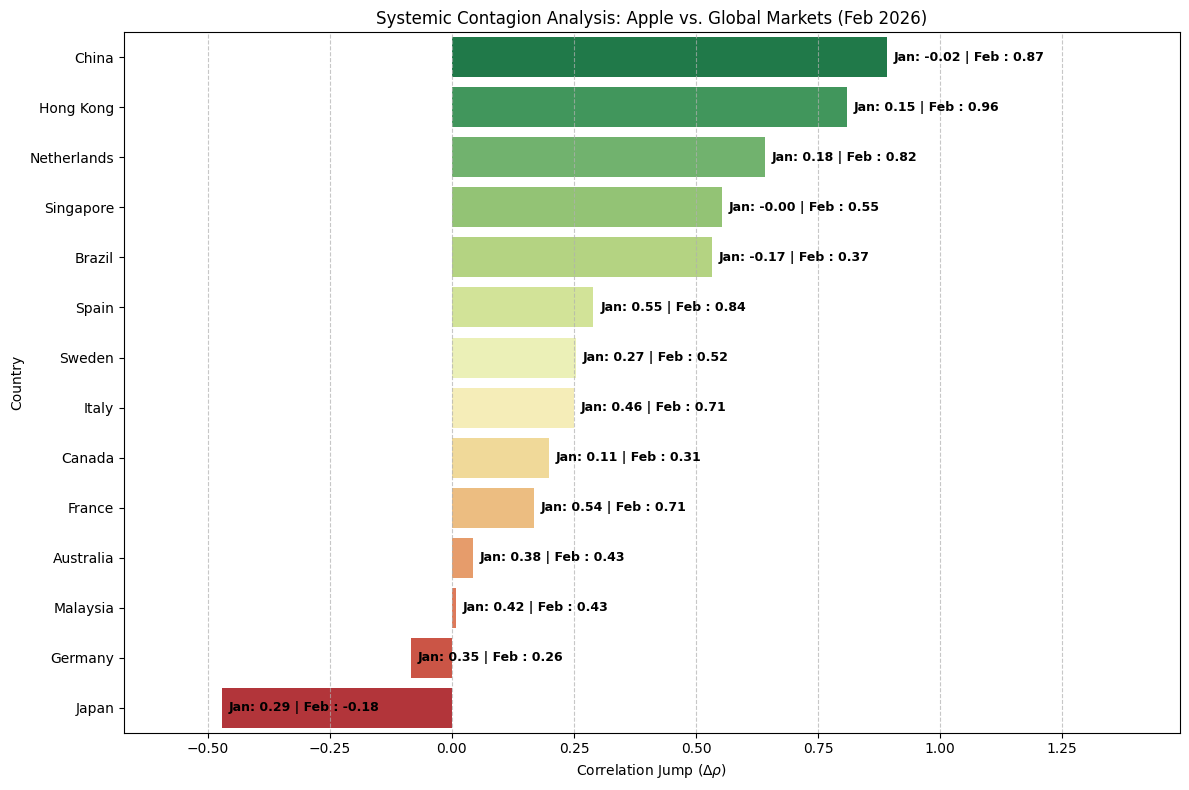

Tabela de Contágio Sistémico (Jan versus Feb 2026):
    Country  Peace_Corr  Stress_Corr     Delta
      China   -0.023810     0.867579  0.891388
  Hong Kong    0.147805     0.957324  0.809519
Netherlands    0.180335     0.821194  0.640859
  Singapore   -0.001396     0.551667  0.553063
     Brazil   -0.167290     0.365104  0.532394
      Spain    0.547042     0.836800  0.289758
     Sweden    0.266216     0.519499  0.253283
      Italy    0.464870     0.714117  0.249248
     Canada    0.108480     0.307696  0.199216
     France    0.538594     0.705991  0.167397
  Australia    0.383121     0.426480  0.043359
   Malaysia    0.424588     0.433342  0.008754
    Germany    0.346536     0.262675 -0.083861
      Japan    0.288778    -0.183029 -0.471807


In [19]:



tickers = ['AAPL', 'EWG', 'EWJ', 'MCHI', 'EWA', 'EWZ', 'EWI', 'EWM', 'EWS', 'EWC', 'EWQ', 'EWP', 'EWH', 'EWD', 'EWN']
countries = ['USA (AAPL)', 'Germany', 'Japan', 'China', 'Australia', 'Brazil', 'Italy', 'Malaysia', 'Singapore', 'Canada', 'France', 'Spain', 'Hong Kong', 'Sweden', 'Netherlands']

peace_period = ("2026-01-05", "2026-02-05")
stress_period = ("2026-02-10", "2026-03-10")


data = yf.download(tickers, start="2026-01-01", end="2026-03-15")['Close']
returns = np.log(data / data.shift(1)).dropna()


corr_peace = returns.loc[peace_period[0]:peace_period[1]].corr()
corr_stress = returns.loc[stress_period[0]:stress_period[1]].corr()


analysis_df = pd.DataFrame({
    'Country': countries[1:],
    'Peace_Corr': corr_peace.loc['AAPL', tickers[1:]].values,
    'Stress_Corr': corr_stress.loc['AAPL', tickers[1:]].values
})


analysis_df['Delta'] = analysis_df['Stress_Corr'] - analysis_df['Peace_Corr']
analysis_df = analysis_df.sort_values(by='Delta', ascending=False)


plt.figure(figsize=(12, 8))

ax = sns.barplot(x='Delta', y='Country', data=analysis_df, palette='RdYlGn_r')


for i, p in enumerate(ax.patches):
    peace_val = analysis_df.iloc[i]['Peace_Corr']
    stress_val = analysis_df.iloc[i]['Stress_Corr']
    ax.annotate(f"Jan: {peace_val:.2f} | Feb : {stress_val:.2f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=9, color='black', weight='bold')

plt.xlabel('Correlation Jump ($\Delta \\rho$)')
plt.title(r'Systemic Contagion Analysis: Apple vs. Global Markets (Feb 2026)')
plt.xlim(analysis_df['Delta'].min() - 0.2, analysis_df['Delta'].max() + 0.6)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("Tabela de Contágio Sistémico (Jan versus Feb 2026):")
print(analysis_df.to_string(index=False))


In [36]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pc

# 1. Dados da Tabela I do teu projeto (Choque de Abril 2025)
data = {
    'Ticker': ['Exxon Mobil', 'Goldman Sachs', 'Microsoft', 'JPMorgan', 'Chevron', 'SPY ETF', 'Alphabet'],
    'Stress_Corr': [0.8603, 0.9154, 0.9056, 0.8431, 0.8665, 0.9535, 0.8710],
    'Delta': [0.6076, 0.4976, 0.4383, 0.4369, 0.4340, 0.3051, 0.2506]
}
df = pd.DataFrame(data)

# 2. Layout Radial: Proximidade baseada no Salto de Correlação (Δρ)
distances = 1 - df['Delta']
angles = np.linspace(0, 2*np.pi, len(df), endpoint=False)
df['x'], df['y'] = distances * np.cos(angles), distances * np.sin(angles)

# OFFSET para os nomes flutuarem bastante acima das bolas
text_offset = 0.18
df['x_text'] = (distances + text_offset) * np.cos(angles)
df['y_text'] = (distances + text_offset) * np.sin(angles)

fig = go.Figure()

# Função para mapear o Salto (Δρ) para a escala RdBu_r
def get_jump_color(val):
    normalized = (val + 1) / 2
    clamped = max(0, min(1, normalized))
    return pc.sample_colorscale('RdBu_r', clamped)[0]

# 3. Adicionar Arestas (Espessura e Cor pelo Salto Δρ)
for i, row in df.iterrows():
    fig.add_trace(go.Scatter(
        x=[0, row['x']], y=[0, row['y']],
        mode='lines',
        line=dict(
            width=row['Delta'] * 45, 
            color=get_jump_color(row['Delta'])
        ),
        opacity=0.6,
        hoverinfo='none'
    ))


fig.add_trace(go.Scatter(
    x=df['x'], y=df['y'],
    mode='markers+text',
    text=[f"{v:.2f}" for v in df['Stress_Corr']], 
    textposition="middle center",
    textfont=dict(color='white', size=11, family="Arial Black"),
    marker=dict(
        size=55, 
        color='black', 
        line=dict(width=3, color=[get_jump_color(d) for d in df['Delta']])
    ),
    hovertext=df['Ticker'],
    hovertemplate="<b>%{hovertext}</b><br>Stress Corr: %{text}<extra></extra>"
))


fig.add_trace(go.Scatter(
    x=df['x_text'], y=df['y_text'],
    mode='text',
    text=df['Ticker'],
    textposition="middle center",
    textfont=dict(size=14, color='black', family="Arial Black"),
    hoverinfo='none'
))


fig.add_trace(go.Scatter(
    x=[0], y=[0.12], 
    mode='text',
    text="Apple",
    textfont=dict(size=16, color='red', family="Arial Black"),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[0], y=[0],
    mode='markers+text',
    text="1.00",
    textposition="middle center",
    textfont=dict(color='white', size=12, family="Arial Black"),
    marker=dict(size=65, color='red', line=dict(width=4, color='darkred')),
    hovertext="Apple (Core)",
    hovertemplate="<b>%{hovertext}</b><extra></extra>"
))

# 7. Configurações Finais
fig.update_layout(
    title="<b>SystemicRisk-Net: Network Contagion</b><br>Inside: Stress Corr | Proximity & Thickness: Δρ Jump",
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-1.4, 1.4]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-1.4, 1.4]),
    plot_bgcolor='white',
    width=900, height=900,
    showlegend=False
)

fig.show()

In [40]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. Dados da Tabela II 
data_geo = {
    'Country': ['China', 'Hong Kong', 'Singapore', 'Netherlands', 'Brazil', 'France', 
                'Spain', 'Italy', 'Sweden', 'Canada', 'Malaysia', 'Australia', 'Germany', 'Japan', 'USA'],
    'Delta': [0.9507, 0.8450, 0.7754, 0.6946, 0.6170, 0.3521, 0.3417, 
              0.2786, 0.2780, 0.1675, 0.1212, 0.1016, -0.0777, -0.5355, 0.0],
    'lat': [35.86, 22.31, 1.35, 52.13, -14.23, 46.22, 40.46, 41.87, 60.12, 56.13, 4.21, -25.27, 51.16, 36.20, 38.89],
    'lon': [104.19, 114.16, 103.81, 5.29, -51.92, -2.21, -3.74, 12.56, 18.64, -106.34, 101.97, 133.77, 10.45, 138.25, -77.03]
}

df_map = pd.DataFrame(data_geo)
df_others = df_map[df_map['Country'] != 'USA'].copy()
df_usa = df_map[df_map['Country'] == 'USA']

# 2. Cálculo do Tamanho com Base Mínima (Floor)
# min_size garante que mesmo 0.0 seja visível
min_size = 12 
scale_factor = 50
df_others['display_size'] = min_size + (df_others['Delta'].abs() * scale_factor)

fig = go.Figure()

# 3. Países Estrangeiros (Escala RdBu_r)
fig.add_trace(go.Scattergeo(
    lat=df_others['lat'],
    lon=df_others['lon'],
    marker=dict(
        size=df_others['display_size'],
        color=df_others['Delta'],
        colorscale='RdBu_r',
        cmin=-1, cmax=1,
        showscale=True,
        colorbar=dict(title="Δρ Jump", thickness=15),
        line=dict(width=1.5, color='black') # Contorno preto para visibilidade
    ),
    text=df_others['Country'],
    hovertemplate="<b>%{text}</b><br>Jump Δρ: %{marker.color:.4f}<extra></extra>"
))

# 4. USA (Origem da Asset) a Verde
fig.add_trace(go.Scattergeo(
    lat=df_usa['lat'],
    lon=df_usa['lon'],
    marker=dict(
        size=35, 
        color='limegreen',
        line=dict(width=2, color='darkgreen')
    ),
    text="USA (Origin)",
    hovertemplate="<b>%{text}</b><extra></extra>"
))

# 5. Configurações de Projeção
fig.update_geos(
    projection_type="natural earth",
    showland=True, landcolor="#f9f9f9",
    showcountries=True, countrycolor="#e0e0e0",
    showocean=True, oceancolor="#ffffff"
)

fig.update_layout(
    title="<b>Global Contagion Cartogram</b><br>Bubble Size = Base (12px) + Magnitude of Δρ",
    margin={"r":0,"t":80,"l":0,"b":0},
    width=1000, height=600,
    showlegend=False
)

fig.show()